In [32]:
import os
import textwrap
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import Patch
from sklearn.ensemble import RandomForestClassifier

In [33]:
# 1. Settings

output_dir = "../results/rf_feature_importance_plots"
os.makedirs(output_dir, exist_ok=True)

top_n = 10
n_runs = 100

# Load selected Random Forest parameters
feasibility_rf_results = joblib.load(
    "../results/rf_feasibility_cv_results.joblib"
)

willingness_rf_results = joblib.load(
    "../results/rf_willingness_cv_results.joblib"
)

rf_params_feasibility = (
    feasibility_rf_results["best_params"].copy()
)

rf_params_willingness = (
    willingness_rf_results["best_params"].copy()
)

print("Feasibility RF parameters:")
print(rf_params_feasibility)

print("\nWillingness RF parameters:")
print(rf_params_willingness)



# 2. Read training data

X_train = pd.read_csv("../data/model_inputs/X_train.csv")

y_train_feasibility = pd.read_csv(
    "../data/model_inputs/y_train_feasibility.csv"
)["feasibility_binary"]

y_train_willingness = pd.read_csv(
    "../data/model_inputs/y_train_willingness.csv"
)["willingness_binary"]


Feasibility RF parameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': None}

Willingness RF parameters:
{'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': None, 'class_weight': None}


In [34]:
# 3. Feature labels

def clean_category_name(x):

    x = str(x).replace("_", " ").strip()

    lower_words = {
        "to", "in", "if", "of", "or",
        "and", "for", "nor", "not",
        "say", "at", "all"
    }

    cleaned_words = []

    for word in x.split():
        if word.lower() in lower_words:
            cleaned_words.append(word.lower())
        elif word.upper() == "COVID":
            cleaned_words.append("COVID")
        elif word.upper() == "N/A":
            cleaned_words.append("N/A")
        else:
            cleaned_words.append(word.capitalize())

    return " ".join(cleaned_words)


FEATURE_LABELS = {

    # Demographics and household
    "age_num": "Age",
    "gender": "Gender",
    "household_size_num": "Household Size",
    "household_children_group": "Children in Household",

    # Employment
    "employment_status": "Employment Status",

    # Contacts / mobility
    "i1_health": "Household Contacts",
    "i2_health": "Non-household Contacts",
    "i7a_health": "Times Left Home",

    # COVID testing / health
    "personal_test_status": "Personal COVID Test",
    "household_test_status": "Household COVID Test",
    "covid_symptom_status": "COVID-like Symptoms",
    "comorbidity_status": "Comorbidities",

    # Time
    "survey_wave": "Survey Wave",

    # Protective behaviours
    "i12_health_1": "Wore Face Mask Outside Home",
    "i12_health_2": "Washed Hands With Soap and Water",
    "i12_health_3": "Used Hand Sanitiser",
    "i12_health_4": "Covered Nose and Mouth When Sneezing or Coughing",
    "i12_health_5": "Avoided Contact With Symptomatic or Exposed People",
    "i12_health_6": "Avoided Going Out Generally",
    "i12_health_7": "Avoided Hospitals or Healthcare Settings",
    "i12_health_8": "Avoided Public Transport",
    "i12_health_11": "Avoided Having Guests at Home",
    "i12_health_12": "Avoided Small Social Gatherings",
    "i12_health_13": "Avoided Medium-sized Social Gatherings",
    "i12_health_14": "Avoided Large Social Gatherings",
    "i12_health_15": "Avoided Crowded Areas",
    "i12_health_16": "Avoided Going to Shops",
    "i12_health_17": "Slept Separately at Home",
    "i12_health_18": "Ate Separately at Home",
    "i12_health_19": "Cleaned Frequently Touched Surfaces",
    "i12_health_20": "Avoided Touching Objects in Public"
}


def readable_feature_name(feature):

    feature = str(feature)

    if feature in FEATURE_LABELS:
        return FEATURE_LABELS[feature]

    # Dummy variables: longest variable names checked first
    for var_code in sorted(FEATURE_LABELS.keys(), key=len, reverse=True):
        prefix = var_code + "_"

        if feature.startswith(prefix):
            variable_label = FEATURE_LABELS[var_code]
            category = feature.replace(prefix, "", 1)

            return (
                f"{variable_label} "
                f"({clean_category_name(category)})"
            )

    return clean_category_name(feature)


def wrap_labels(labels, width=34):
    return [
        "\n".join(textwrap.wrap(str(label), width=width))
        for label in labels
    ]


# 4. Feature groups and colours

FEATURE_GROUPS = {

    # Demographics and household
    "age_num": "Demographics and household",
    "gender": "Demographics and household",
    "household_size_num": "Demographics and household",
    "household_children_group": "Demographics and household",

    # Employment
    "employment_status": "Employment",

    # Protective behaviours
    "i12_health_1": "Protective behaviours",
    "i12_health_2": "Protective behaviours",
    "i12_health_3": "Protective behaviours",
    "i12_health_4": "Protective behaviours",
    "i12_health_5": "Protective behaviours",
    "i12_health_6": "Protective behaviours",
    "i12_health_7": "Protective behaviours",
    "i12_health_8": "Protective behaviours",
    "i12_health_11": "Protective behaviours",
    "i12_health_12": "Protective behaviours",
    "i12_health_13": "Protective behaviours",
    "i12_health_14": "Protective behaviours",
    "i12_health_15": "Protective behaviours",
    "i12_health_16": "Protective behaviours",
    "i12_health_17": "Protective behaviours",
    "i12_health_18": "Protective behaviours",
    "i12_health_19": "Protective behaviours",
    "i12_health_20": "Protective behaviours",

    # Contacts and mobility
    "i1_health": "Contacts and mobility",
    "i2_health": "Contacts and mobility",
    "i7a_health": "Contacts and mobility",

    # Health
    "personal_test_status": "Health and COVID experience",
    "household_test_status": "Health and COVID experience",
    "covid_symptom_status": "Health and COVID experience",
    "comorbidity_status": "Health and COVID experience",

    # Time
    "survey_wave": "Time"
}


GROUP_COLORS = {
    "Protective behaviours": "#1f77b4",
    "Demographics and household": "#2ca02c",
    "Employment": "#ff7f0e",
    "Contacts and mobility": "#9467bd",
    "Health and COVID experience": "#d62728",
    "Time": "#ffbf00",
    "Other": "#999999"
}


def get_feature_group(feature):
    feature = str(feature)

    if feature in FEATURE_GROUPS:
        return FEATURE_GROUPS[feature]

    for var_code in sorted(FEATURE_GROUPS.keys(), key=len, reverse=True):
        prefix = var_code + "_"

        if feature.startswith(prefix):
            return FEATURE_GROUPS[var_code]

    return "Other"


# 5. Map each model column back to its original predictor

def get_original_feature(feature):

    feature = str(feature)

    # Check longer variable codes first to avoid partial matching
    for original_feature in sorted(
        FEATURE_LABELS.keys(),
        key=len,
        reverse=True
    ):
        if (
            feature == original_feature
            or feature.startswith(original_feature + "_")
        ):
            return original_feature

    # Keep unmatched variables under their existing names
    return feature


# 6. Repeated RF fitting and variable-level importance extraction

def get_rf_importance(
    X_train,
    y_train,
    model_params,
    n_runs=100
):
    all_importances = []

    # Map every model column to its original predictor once
    feature_mapping = pd.DataFrame({
        "Feature_dummy": X_train.columns
    })

    feature_mapping["Feature"] = (
        feature_mapping["Feature_dummy"]
        .apply(get_original_feature)
    )

    for seed in range(n_runs):

        model = RandomForestClassifier(
            random_state=seed,
            n_jobs=-1,
            **model_params
        )

        model.fit(X_train, y_train)

        # Dummy-level importance for this RF run
        run_importance = pd.DataFrame({
            "Feature_dummy": X_train.columns,
            "Importance": model.feature_importances_
        })

        # Attach original predictor names
        run_importance = run_importance.merge(
            feature_mapping,
            on="Feature_dummy",
            how="left"
        )

        # Sum all dummy-category importance values belonging
        # to the same original predictor within this run
        run_variable_importance = (
            run_importance
            .groupby(
                "Feature",
                as_index=False
            )["Importance"]
            .sum()
        )

        run_variable_importance["Run"] = seed

        all_importances.append(
            run_variable_importance
        )

    importance_all = pd.concat(
        all_importances,
        ignore_index=True
    )

    # Summarise variable-level importance across repeated RF runs
    importance_df = (
        importance_all
        .groupby("Feature")["Importance"]
        .agg(
            Importance="median",
            Q1=lambda x: np.percentile(x, 25),
            Q3=lambda x: np.percentile(x, 75)
        )
        .reset_index()
        .sort_values(
            by="Importance",
            ascending=False
        )
        .reset_index(drop=True)
    )

    return importance_df


# 7. Prepare Top-10 union comparison table

def prepare_feasibility_willingness_df(
    feasibility_df,
    willingness_df,
    top_n_each=top_n
):
    # Determine which predictors appear in either Top-N list
    feasibility_top_features = set(
        feasibility_df.head(top_n_each)["Feature"]
    )

    willingness_top_features = set(
        willingness_df.head(top_n_each)["Feature"]
    )

    selected_features = (
        feasibility_top_features
        | willingness_top_features
    )

    # Keep the true importance values from the complete tables
    feasibility_all = feasibility_df[
        ["Feature", "Importance", "Q1", "Q3"]
    ].copy()

    feasibility_all = feasibility_all.rename(columns={
        "Importance": "Feasibility",
        "Q1": "Feasibility_Q1",
        "Q3": "Feasibility_Q3"
    })

    willingness_all = willingness_df[
        ["Feature", "Importance", "Q1", "Q3"]
    ].copy()

    willingness_all = willingness_all.rename(columns={
        "Importance": "Willingness",
        "Q1": "Willingness_Q1",
        "Q3": "Willingness_Q3"
    })

    # Merge complete importance tables
    merged = pd.merge(
        feasibility_all,
        willingness_all,
        on="Feature",
        how="inner"
    )

    # Display only predictors appearing in either Top-N list
    merged = merged[
        merged["Feature"].isin(selected_features)
    ].copy()

    # Full-model ranks
    feasibility_rank_map = {
        feature: rank + 1
        for rank, feature in enumerate(
            feasibility_df["Feature"]
        )
    }

    willingness_rank_map = {
        feature: rank + 1
        for rank, feature in enumerate(
            willingness_df["Feature"]
        )
    }

    merged["Feasibility_Rank"] = merged["Feature"].map(
        feasibility_rank_map
    )

    merged["Willingness_Rank"] = merged["Feature"].map(
        willingness_rank_map
    )

    merged["Feature_raw"] = merged["Feature"]

    merged["Group"] = merged["Feature_raw"].apply(
        get_feature_group
    )

    merged["Feature"] = merged["Feature_raw"].apply(
        readable_feature_name
    )

    # Order by combined importance
    merged["Total"] = (
        merged["Feasibility"]
        + merged["Willingness"]
    )

    # Feasibility shown on the left
    merged["Feasibility"] = -merged["Feasibility"]
    merged["Feasibility_Q1"] = -merged["Feasibility_Q1"]
    merged["Feasibility_Q3"] = -merged["Feasibility_Q3"]

    merged = merged.sort_values(
        "Total",
        ascending=True
    ).reset_index(drop=True)

    return merged


# 8. Plot mirrored feasibility-willingness comparison

def plot_feasibility_willingness(plot_df, save_path):

    plt.figure(figsize=(15, max(9, len(plot_df) * 0.55)))

    axis_label_size = 15
    tick_label_size = 13
    legend_size = 13

    y_pos = np.arange(len(plot_df))

    bar_colors = plot_df["Group"].map(
        GROUP_COLORS
    ).fillna("#999999")

    # Feasibility error bars, shown on the left as negative values
    feasibility_left_error = (
        plot_df["Feasibility"]
        - plot_df["Feasibility_Q3"]
    ).abs()

    feasibility_right_error = (
        plot_df["Feasibility_Q1"]
        - plot_df["Feasibility"]
    ).abs()

    feasibility_xerr = np.vstack([
        feasibility_left_error,
        feasibility_right_error
    ])

    # Willingness error bars, shown on right
    willingness_left_error = (
        plot_df["Willingness"]
        - plot_df["Willingness_Q1"]
    ).abs()

    willingness_right_error = (
        plot_df["Willingness_Q3"]
        - plot_df["Willingness"]
    ).abs()

    willingness_xerr = np.vstack([
        willingness_left_error,
        willingness_right_error
    ])

    # Left: feasibility
    plt.barh(
        y_pos,
        plot_df["Feasibility"],
        color=bar_colors,
        xerr=feasibility_xerr,
        error_kw={
            "ecolor": "black",
            "elinewidth": 1.0,
            "capsize": 3
        }
    )

    # Right: willingness
    plt.barh(
        y_pos,
        plot_df["Willingness"],
        color=bar_colors,
        xerr=willingness_xerr,
        error_kw={
            "ecolor": "black",
            "elinewidth": 1.0,
            "capsize": 3
        }
    )

    plt.axvline(
        0,
        color="black",
        linewidth=1.2
    )

    plt.yticks(
        y_pos,
        wrap_labels(plot_df["Feature"], width=37),
        fontsize=tick_label_size
    )

    plt.xlabel(
        "Median Random Forest feature importance",
        fontsize=axis_label_size
    )

    # Determine symmetric axis limits
    max_value = max(
        plot_df["Feasibility"].abs().max(),
        plot_df["Willingness"].abs().max(),
        plot_df["Feasibility_Q1"].abs().max(),
        plot_df["Feasibility_Q3"].abs().max(),
        plot_df["Willingness_Q1"].abs().max(),
        plot_df["Willingness_Q3"].abs().max()
    )

    axis_limit = max_value * 1.25

    plt.xlim(-axis_limit, axis_limit)

    ticks = np.linspace(
        -axis_limit,
        axis_limit,
        7
    )

    tick_labels = [
        f"{abs(t):.3f}"
        for t in ticks
    ]

    plt.xticks(
        ticks,
        tick_labels,
        fontsize=tick_label_size
    )

    # Labels above each side
    plt.text(
        -axis_limit * 0.5,
        len(plot_df) - 0.2,
        "Feasibility",
        ha="center",
        va="bottom",
        fontsize=16,
        fontweight="bold"
    )

    plt.text(
        axis_limit * 0.5,
        len(plot_df) - 0.2,
        "Willingness",
        ha="center",
        va="bottom",
        fontsize=16,
        fontweight="bold"
    )

    legend_order = [
        "Protective behaviours",
        "Demographics and household",
        "Employment",
        "Contacts and mobility",
        "Health and COVID experience",
        "Time",
        "Other"
    ]

    handles = []

    for group in legend_order:
        if group in plot_df["Group"].unique():
            handles.append(
                Patch(
                    facecolor=GROUP_COLORS[group],
                    label=group
                )
            )

    plt.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.12),
        ncol=3,
        frameon=False,
        fontsize=legend_size
    )

    plt.grid(axis="x", alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# 9. Define function for printing Top-10 results

def print_top_features(importance_df, title, top_n=10):

    print(f"\n===== {title} =====")

    print(
        importance_df
        .head(top_n)[["Feature", "Importance", "Q1", "Q3"]]
        .to_string(index=False)
    )

In [35]:
# 10. Run repeated variable-level RF importance analysis

importance_feasibility = get_rf_importance(
    X_train=X_train,
    y_train=y_train_feasibility,
    model_params=rf_params_feasibility,
    n_runs=n_runs
)

importance_willingness = get_rf_importance(
    X_train=X_train,
    y_train=y_train_willingness,
    model_params=rf_params_willingness,
    n_runs=n_runs
)

In [36]:
# 11. Print Top-10 results and save complete variable-level importance tables

print_top_features(
    importance_df=importance_feasibility,
    title="Feasibility: Top 10 RF predictors (variable level)",
    top_n=top_n
)

print_top_features(
    importance_df=importance_willingness,
    title="Willingness: Top 10 RF predictors (variable level)",
    top_n=top_n
)

importance_feasibility.to_csv(
    (
        f"{output_dir}/"
        "rf_feasibility_variable_level_feature_importance.csv"
    ),
    index=False
)

importance_willingness.to_csv(
    (
        f"{output_dir}/"
        "rf_willingness_variable_level_feature_importance.csv"
    ),
    index=False
)


===== Feasibility: Top 10 RF predictors (variable level) =====
          Feature  Importance       Q1       Q3
      survey_wave    0.073119 0.072635 0.073561
          age_num    0.056029 0.055606 0.056542
     i12_health_5    0.044007 0.043476 0.044411
     i12_health_1    0.043961 0.043255 0.044748
     i12_health_4    0.040904 0.040414 0.041599
        i2_health    0.040148 0.039877 0.040696
    i12_health_15    0.037901 0.037351 0.038345
employment_status    0.036522 0.036211 0.036907
     i12_health_2    0.035885 0.035586 0.036364
     i12_health_3    0.035305 0.034961 0.035606

===== Willingness: Top 10 RF predictors (variable level) =====
      Feature  Importance       Q1       Q3
      age_num    0.063495 0.063141 0.063722
  survey_wave    0.052298 0.052039 0.052586
 i12_health_5    0.051354 0.050755 0.051747
    i2_health    0.048836 0.048601 0.049030
 i12_health_1    0.045772 0.045426 0.046184
 i12_health_4    0.042375 0.041988 0.042744
 i12_health_3    0.037191 0.036934 0

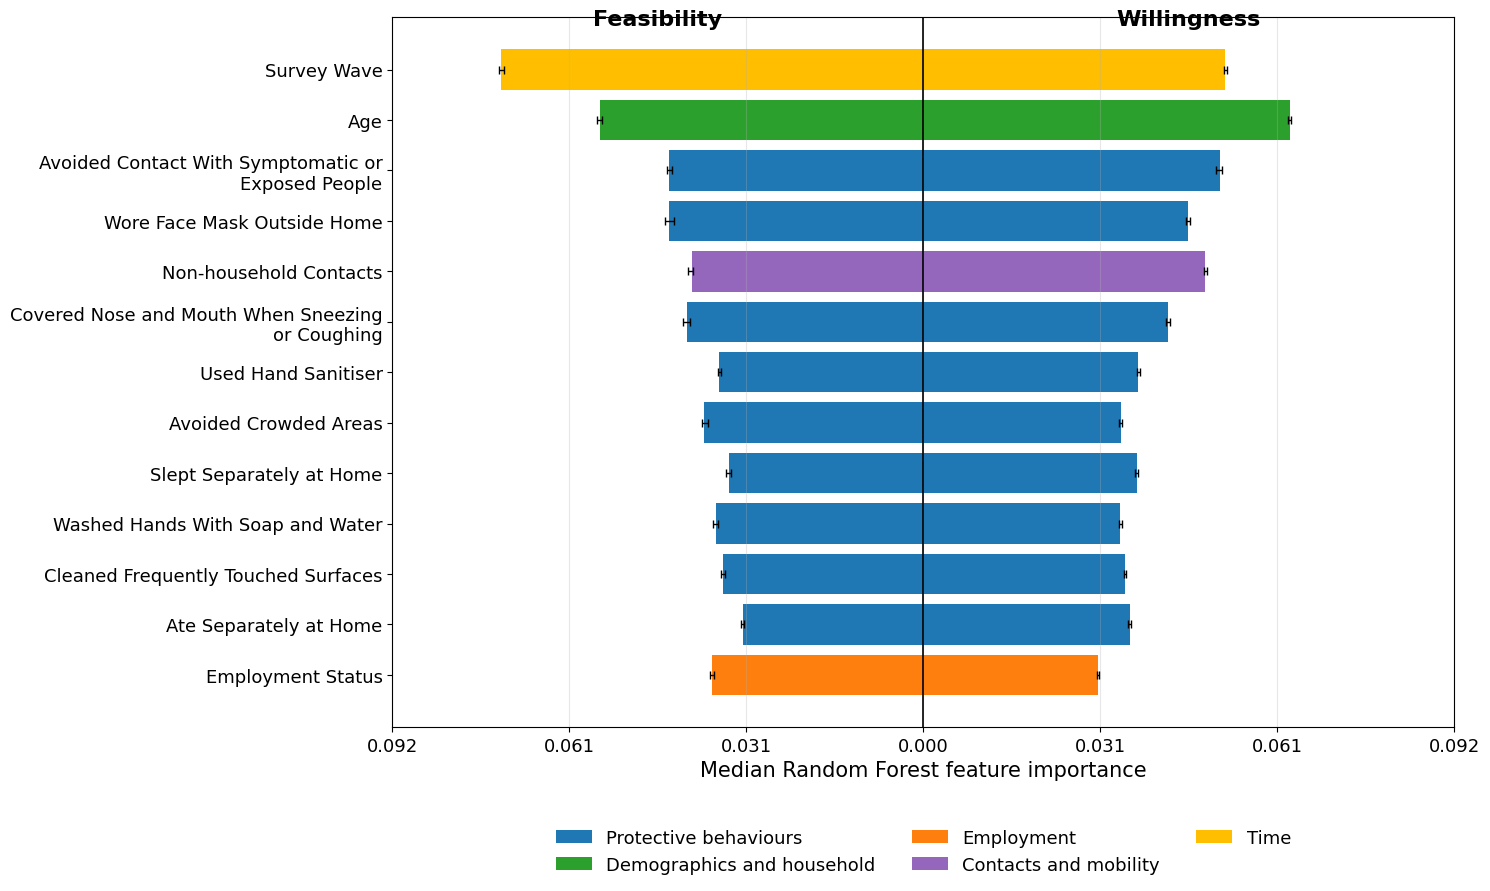

In [37]:
# 12. Build the union of the two variable-level Top-10 lists and create the comparison plot

plot_df = prepare_feasibility_willingness_df(
    feasibility_df=importance_feasibility,
    willingness_df=importance_willingness,
    top_n_each=top_n
)

plot_df.to_csv(
    (
        f"{output_dir}/"
        "rf_feasibility_willingness_"
        "top10_variable_union.csv"
    ),
    index=False
)

plot_feasibility_willingness(
    plot_df=plot_df,
    save_path=(
        f"{output_dir}/"
        "rf_feasibility_willingness_"
        "top10_variable_comparison.png"
    )
)

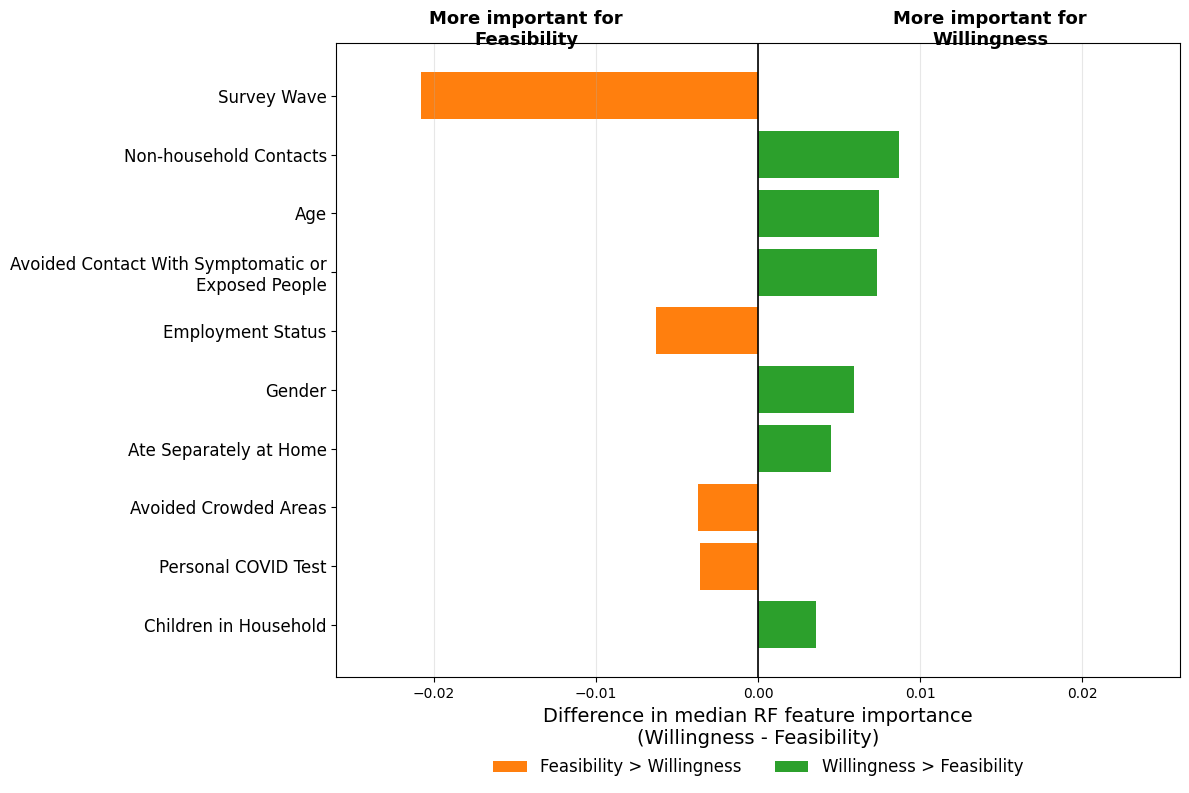

In [38]:
# 13. Prepare the variable-level RF importance difference table
# Difference = Willingness importance - Feasibility importance
# Right side: more important for willingness
# Left side: more important for feasibility

def prepare_importance_difference_df(
    feasibility_df,
    willingness_df,
    top_n_difference=top_n
):
    feasibility_all = feasibility_df[
        ["Feature", "Importance"]
    ].copy()

    feasibility_all = feasibility_all.rename(columns={
        "Importance": "Feasibility"
    })

    willingness_all = willingness_df[
        ["Feature", "Importance"]
    ].copy()

    willingness_all = willingness_all.rename(columns={
        "Importance": "Willingness"
    })

    # Merge all predictors with their true importance values
    diff_df = pd.merge(
        feasibility_all,
        willingness_all,
        on="Feature",
        how="inner"
    )

    # Calculate true difference
    diff_df["Difference"] = (
        diff_df["Willingness"]
        - diff_df["Feasibility"]
    )

    diff_df["Abs_Difference"] = (
        diff_df["Difference"].abs()
    )

    # Select predictors with the largest absolute differences
    diff_df = (
        diff_df
        .nlargest(top_n_difference, "Abs_Difference")
        .copy()
    )

    diff_df["Feature_raw"] = diff_df["Feature"]

    diff_df["Feature"] = diff_df["Feature_raw"].apply(
        readable_feature_name
    )

    # Ascending order so the largest bar appears at the top
    diff_df = diff_df.sort_values(
        "Abs_Difference",
        ascending=True
    ).reset_index(drop=True)

    return diff_df


# 14. Plot variable-level RF importance differences

def plot_importance_difference(diff_df, save_path):

    plt.figure(figsize=(12, max(8, len(diff_df) * 0.5)))

    y_pos = np.arange(len(diff_df))

    colors = np.where(
        diff_df["Difference"] >= 0,
        "#2ca02c",   # Willingness larger
        "#ff7f0e"    # Feasibility larger
    )

    plt.barh(
        y_pos,
        diff_df["Difference"],
        color=colors
    )

    plt.axvline(
        0,
        color="black",
        linewidth=1.2
    )

    plt.yticks(
        y_pos,
        wrap_labels(diff_df["Feature"], width=38),
        fontsize=12
    )

    plt.xlabel(
        "Difference in median RF feature importance\n"
        "(Willingness - Feasibility)",
        fontsize=14
    )

    max_abs = diff_df["Difference"].abs().max()
    axis_limit = max_abs * 1.25

    plt.xlim(-axis_limit, axis_limit)

    plt.text(
        -axis_limit * 0.55,
        len(diff_df) - 0.2,
        "More important for\nFeasibility",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold"
    )

    plt.text(
        axis_limit * 0.55,
        len(diff_df) - 0.2,
        "More important for\nWillingness",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold"
    )

    legend_handles = [
        Patch(facecolor="#ff7f0e", label="Feasibility > Willingness"),
        Patch(facecolor="#2ca02c", label="Willingness > Feasibility")
    ]

    plt.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=2,
        frameon=False,
        fontsize=12
    )

    plt.grid(axis="x", alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    

# 15. Create and save the variable-level Top-10 difference plot

difference_df = prepare_importance_difference_df(
    feasibility_df=importance_feasibility,
    willingness_df=importance_willingness,
    top_n_difference=top_n
)

difference_df.to_csv(
    (
        f"{output_dir}/"
        "rf_variable_level_top10_importance_differences.csv"
    ),
    index=False
)

plot_importance_difference(
    diff_df=difference_df,
    save_path=(
        f"{output_dir}/"
        "rf_variable_level_top10_importance_differences.png"
    )
)